In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Exploration: Load and visualize the data.**

In [51]:
df = pd.read_csv('/content/ex2data1.txt')
df.columns = ['1', '2', 'accept']
df.head()

,1,2,accept
0,30.286711,43.894998,0
1,35.847409,72.902198,0
2,60.182599,86.308552,1
3,79.032736,75.344376,1
4,45.083277,56.316372,0


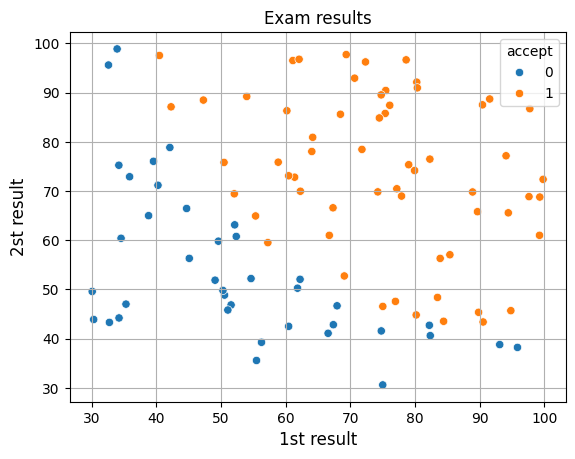

In [55]:
sns.scatterplot(data=df, x='1', y='2', hue='accept')

plt.title('Exam results')
plt.xlabel('1st result', fontsize = 12)
plt.ylabel('2st result', fontsize = 12)

# plt.legend(title='Статус зачисления')
plt.grid(True) # Добавляем сетку для удобства
plt.show()



**Applying Logistic Regression with scikit-learn:**

* Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.

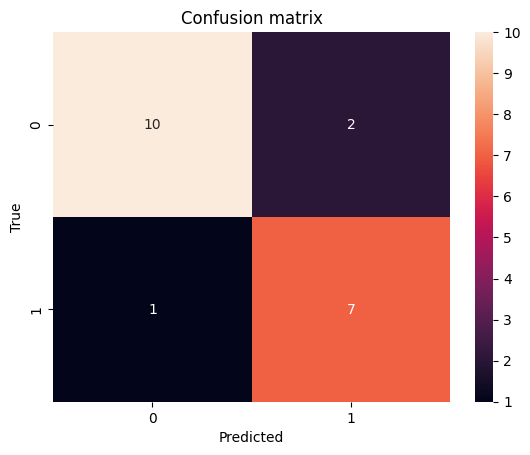

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        12
           1       0.78      0.88      0.82         8

    accuracy                           0.85        20
   macro avg       0.84      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20



In [71]:
from logging import log
import sklearn
from sklearn.linear_model import LogisticRegression

data_split = sklearn.model_selection.train_test_split(df[['1', '2']], df['accept'], test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = data_split

data_skaling = sklearn.preprocessing.StandardScaler()
X_train = data_skaling.fit_transform(X_train)
X_test = data_skaling.transform(X_test)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

sklearn.metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print_samary = sklearn.metrics.classification_report(y_test, y_pred)
print(print_samary)

**Precision**
* Definition: Of all the times the model predicted "Yes" (admitted), what percentage was correct?
* Your score of 0.78 means: When the model predicts a student will be admitted, it is correct 78% of the time.

**Recall**
* Definition: Of all the students who were actually admitted, what percentage did the model find?
* Your score of 0.88 means: The model successfully found 88% of all the students who were truly admitted.

**F1-score**
* Definition: A single score that represents the balance between Precision and Recall.
* Your score of 0.82 means: You have a good, balanced model that performs well on both precision and recall, with 82% being a strong overall score.